#### Predict the salary of the emeployees based on the years of experience using Polynomial Linear Regression


##### Step 1: Import all the necessary libraries

In [786]:
import  numpy               as  np
import  pandas              as  pd
import  matplotlib.pyplot   as  plt
import  seaborn             as  sns

from    sklearn.model_selection       import    train_test_split
from    sklearn.preprocessing         import    StandardScaler  , PolynomialFeatures
from    sklearn.linear_model          import    LinearRegression
from    sklearn.metrics               import    mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score

#### Step 2:    Load the Dataset

In [787]:
df  =  pd.read_csv("Salary_Data.csv")

In [788]:
df

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


#### OBSERVATIONS:

1.  The above dataset contains two columns:---

    (a.)  YearsExperience --------------->   Years of experience for each employee

    (b.)  Salary          --------------->   Salary earned by the employee based on the years of experience.

#### Step 3: Perform the Data Exploration

In [789]:
#### get the total records used in the dataframe

print("Total records used in the dataframe is:", len(df))

Total records used in the dataframe is: 30


In [790]:
#### get the shape of the dataframe

print("Shape of the dataframe is:", df.shape)

Shape of the dataframe is: (30, 2)


In [791]:
#### get the columns used in the dataframe

print("Columns used are :", df.columns)

Columns used are : Index(['YearsExperience', 'Salary'], dtype='object')


In [792]:
#### get the information about each column used in the dataset

print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   YearsExperience  30 non-null     float64
 1   Salary           30 non-null     float64
dtypes: float64(2)
memory usage: 612.0 bytes
None


In [793]:
#### get the statistical summary about every column used in the dataset

print(df.describe())

       YearsExperience         Salary
count        30.000000      30.000000
mean          5.313333   76003.000000
std           2.837888   27414.429785
min           1.100000   37731.000000
25%           3.200000   56720.750000
50%           4.700000   65237.000000
75%           7.700000  100544.750000
max          10.500000  122391.000000


In [794]:
#### get the correlation between all the columns used in the dataset

df.corr()

,YearsExperience,Salary
YearsExperience,1.000000,0.978242
Salary,0.978242,1.000000


<Axes: >

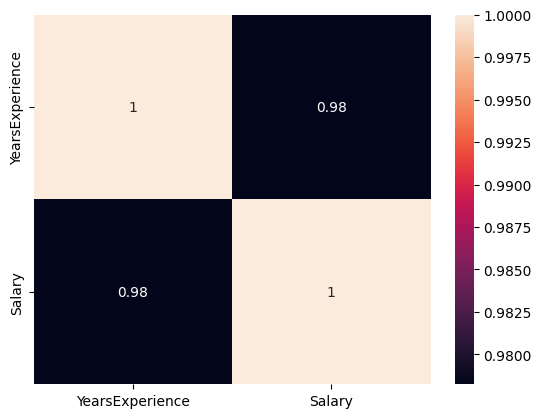

In [795]:
#### get the graphical representation for the correlation between all the columns used in the dataset

sns.heatmap(df.corr(), annot=True)

#### OBSERVATIONS:

1.  There is a very high correlation between YearsExperience and Salary.

#### Step 4:    Perform the Data Cleaning

In [796]:
### Check if there are any NULL records used in the dataset

df.isnull().sum()

YearsExperience    0
Salary             0
dtype: int64

#### OBSERVATIONS:

1.  There are no NULL records in the dataset.

In [797]:
#### Check if there are any duplicate records in the dataset

df[df.duplicated()]

,YearsExperience,Salary


#### OBSERVATIONS:

1.  There are no duplicate records used in the dataset.

#### Step 5: Divide the dataset into independent and dependent features

In [798]:
#### Independent features

X = df[['YearsExperience']]

In [799]:
print(X)

    YearsExperience
0               1.1
1               1.3
2               1.5
3               2.0
4               2.2
5               2.9
6               3.0
7               3.2
8               3.2
9               3.7
10              3.9
11              4.0
12              4.0
13              4.1
14              4.5
15              4.9
16              5.1
17              5.3
18              5.9
19              6.0
20              6.8
21              7.1
22              7.9
23              8.2
24              8.7
25              9.0
26              9.5
27              9.6
28             10.3
29             10.5


In [800]:
#### Dependent features

Y = df['Salary']

In [801]:
print(Y)

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64


#### OBSERVATIONS:

1.  The dataset is divided into the independent and dependent variables.

#### Step 6:    Divide the independent and dependent features into the training and testing data

In [802]:
from sklearn.model_selection import train_test_split

X_train, X_test , Y_train, Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [803]:
X_train

,YearsExperience
28,10.3
24,8.7
12,4.0
0,1.1
4,2.2
16,5.1
5,2.9
13,4.1
11,4.0
22,7.9


In [804]:
X_test

,YearsExperience
27,9.6
15,4.9
23,8.2
17,5.3
8,3.2
9,3.7


In [805]:
print("Shape of the input training data is:", X_train.shape)
print("Shape of the input testing  data is:", X_test.shape)

Shape of the input training data is: (24, 1)
Shape of the input testing  data is: (6, 1)


In [806]:
Y_train

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
16     66029.0
5      56642.0
13     57081.0
11     55794.0
22    101302.0
1      46205.0
2      37731.0
25    105582.0
3      43525.0
21     98273.0
26    116969.0
18     81363.0
29    121872.0
20     91738.0
7      54445.0
10     63218.0
14     61111.0
19     93940.0
6      60150.0
Name: Salary, dtype: float64

In [807]:
Y_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

In [808]:
print("Shape of the output training data is:", Y_train.shape)
print("Shape of the output testing  data is:", Y_test.shape)

Shape of the output training data is: (24,)
Shape of the output testing  data is: (6,)


#### OBSERVATIONS:

1. The dataset is divided into the training and testing data.

    (a.)  Training data --------------->    80 % data

    (b.)  Testing  data --------------->    20 % data

#### Step 7: Train the Linear Regression

In [809]:
from sklearn.linear_model import LinearRegression

#### create the object using Linear Regression

lin = LinearRegression()

#### using the object of linear regression, train the model

lin.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### OBSERVATIONS:

1.  The linear regression model has been trained using the training data.

#### Step 8: Predict the Model

In [810]:
Y_pred = lin.predict(X_test)

In [811]:
Y_pred

array([115790.21011287,  71498.27809463, 102596.86866063,  75267.80422384,
        55477.79204548,  60189.69970699])

#### Step 9: Evaluate the Regression Metrics

In [812]:
from sklearn.metrics import r2_score

r2 = r2_score(Y_test, Y_pred)

print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.9024461774180497


#### Step 10: Improve the model using Polynomial Features

In [813]:
#### Use the Polynomial degree with degree ('3')

from sklearn.preprocessing import PolynomialFeatures

#### create an object for Polynomial Features
poly = PolynomialFeatures(degree=3)

#### using the object of polynomial features, transform the input data

X_new = df[['YearsExperience']]

Y_new = df['Salary']

In [814]:
X_new

,YearsExperience
0,1.1
1,1.3
2,1.5
3,2.0
4,2.2
5,2.9
6,3.0
7,3.2
8,3.2
9,3.7


In [815]:
Y_new

0      39343.0
1      46205.0
2      37731.0
3      43525.0
4      39891.0
5      56642.0
6      60150.0
7      54445.0
8      64445.0
9      57189.0
10     63218.0
11     55794.0
12     56957.0
13     57081.0
14     61111.0
15     67938.0
16     66029.0
17     83088.0
18     81363.0
19     93940.0
20     91738.0
21     98273.0
22    101302.0
23    113812.0
24    109431.0
25    105582.0
26    116969.0
27    112635.0
28    122391.0
29    121872.0
Name: Salary, dtype: float64

In [816]:
#### Make the input features and transform it to degree as 3

from sklearn.preprocessing import PolynomialFeatures

##### create an object for Polynomial Features

poly = PolynomialFeatures(degree=3)

##### using the object for Polynomial features, transform the input

X_poly = poly.fit_transform(X_new)

print(X_poly)

[[1.000000e+00 1.100000e+00 1.210000e+00 1.331000e+00]
 [1.000000e+00 1.300000e+00 1.690000e+00 2.197000e+00]
 [1.000000e+00 1.500000e+00 2.250000e+00 3.375000e+00]
 [1.000000e+00 2.000000e+00 4.000000e+00 8.000000e+00]
 [1.000000e+00 2.200000e+00 4.840000e+00 1.064800e+01]
 [1.000000e+00 2.900000e+00 8.410000e+00 2.438900e+01]
 [1.000000e+00 3.000000e+00 9.000000e+00 2.700000e+01]
 [1.000000e+00 3.200000e+00 1.024000e+01 3.276800e+01]
 [1.000000e+00 3.200000e+00 1.024000e+01 3.276800e+01]
 [1.000000e+00 3.700000e+00 1.369000e+01 5.065300e+01]
 [1.000000e+00 3.900000e+00 1.521000e+01 5.931900e+01]
 [1.000000e+00 4.000000e+00 1.600000e+01 6.400000e+01]
 [1.000000e+00 4.000000e+00 1.600000e+01 6.400000e+01]
 [1.000000e+00 4.100000e+00 1.681000e+01 6.892100e+01]
 [1.000000e+00 4.500000e+00 2.025000e+01 9.112500e+01]
 [1.000000e+00 4.900000e+00 2.401000e+01 1.176490e+02]
 [1.000000e+00 5.100000e+00 2.601000e+01 1.326510e+02]
 [1.000000e+00 5.300000e+00 2.809000e+01 1.488770e+02]
 [1.000000

In [817]:
#### Divide the independent and dependent features into the training and testing data

from sklearn.model_selection import train_test_split

X_poly_train, X_poly_test , Y_poly_train, Y_poly_test = train_test_split(X_poly,Y,test_size=0.2,random_state=42)

In [818]:
X_poly_train

array([[1.000000e+00, 1.030000e+01, 1.060900e+02, 1.092727e+03],
       [1.000000e+00, 8.700000e+00, 7.569000e+01, 6.585030e+02],
       [1.000000e+00, 4.000000e+00, 1.600000e+01, 6.400000e+01],
       [1.000000e+00, 1.100000e+00, 1.210000e+00, 1.331000e+00],
       [1.000000e+00, 2.200000e+00, 4.840000e+00, 1.064800e+01],
       [1.000000e+00, 5.100000e+00, 2.601000e+01, 1.326510e+02],
       [1.000000e+00, 2.900000e+00, 8.410000e+00, 2.438900e+01],
       [1.000000e+00, 4.100000e+00, 1.681000e+01, 6.892100e+01],
       [1.000000e+00, 4.000000e+00, 1.600000e+01, 6.400000e+01],
       [1.000000e+00, 7.900000e+00, 6.241000e+01, 4.930390e+02],
       [1.000000e+00, 1.300000e+00, 1.690000e+00, 2.197000e+00],
       [1.000000e+00, 1.500000e+00, 2.250000e+00, 3.375000e+00],
       [1.000000e+00, 9.000000e+00, 8.100000e+01, 7.290000e+02],
       [1.000000e+00, 2.000000e+00, 4.000000e+00, 8.000000e+00],
       [1.000000e+00, 7.100000e+00, 5.041000e+01, 3.579110e+02],
       [1.000000e+00, 9.5

In [819]:
X_poly_test

array([[  1.   ,   9.6  ,  92.16 , 884.736],
       [  1.   ,   4.9  ,  24.01 , 117.649],
       [  1.   ,   8.2  ,  67.24 , 551.368],
       [  1.   ,   5.3  ,  28.09 , 148.877],
       [  1.   ,   3.2  ,  10.24 ,  32.768],
       [  1.   ,   3.7  ,  13.69 ,  50.653]])

In [820]:
print("Shape of the input training data is:", X_poly_train.shape)
print("Shape of the input testing  data is:", X_poly_test.shape)

Shape of the input training data is: (24, 4)
Shape of the input testing  data is: (6, 4)


In [821]:
Y_poly_train

28    122391.0
24    109431.0
12     56957.0
0      39343.0
4      39891.0
16     66029.0
5      56642.0
13     57081.0
11     55794.0
22    101302.0
1      46205.0
2      37731.0
25    105582.0
3      43525.0
21     98273.0
26    116969.0
18     81363.0
29    121872.0
20     91738.0
7      54445.0
10     63218.0
14     61111.0
19     93940.0
6      60150.0
Name: Salary, dtype: float64

In [822]:
Y_poly_test

27    112635.0
15     67938.0
23    113812.0
17     83088.0
8      64445.0
9      57189.0
Name: Salary, dtype: float64

In [823]:
print("Shape of the output training data is:", Y_poly_train.shape)
print("Shape of the output testing  data is:", Y_poly_test.shape)

Shape of the output training data is: (24,)
Shape of the output testing  data is: (6,)


In [824]:
#### Train the model for Polynomial Features

from  sklearn.linear_model import LinearRegression

#### create an object for Linear Regression

lin_poly = LinearRegression()

#### using the polynomial object train the model

lin_poly.fit(X_poly_train, Y_poly_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


#### OBSERVATIONS:

1.  The model has been trained usig the training polynomial features data.

In [825]:
#### predict the model

Y_pred_poly = lin_poly.predict(X_poly_test)

In [826]:
Y_pred_poly

array([116720.83404343,  70046.26332269, 105553.61621037,  74446.73204807,
        53159.8488299 ,  57707.67750785])

In [827]:
##### Compare the Actual vs Predicted results and store the Residual in the dataframe

res = pd.DataFrame({
    'Actual Results'        :            Y_poly_test       ,
    'Predicted Results'     :            Y_pred_poly       ,
    'Residuals'             :            (Y_poly_test  - Y_pred_poly)    
})

In [828]:
res

,Actual Results,Predicted Results,Residuals
27,112635.0,116720.834043,-4085.834043
15,67938.0,70046.263323,-2108.263323
23,113812.0,105553.616210,8258.383790
17,83088.0,74446.732048,8641.267952
8,64445.0,53159.848830,11285.151170
9,57189.0,57707.677508,-518.677508


In [829]:
#### Perform the Regression Metrics

from sklearn.metrics  import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score


mae = mean_absolute_error(Y_poly_test, Y_pred_poly)

print("Mean Absolute Error of the model is:", mae)

Mean Absolute Error of the model is: 5816.262964271654


In [830]:
mse = mean_squared_error(Y_poly_test, Y_pred_poly)

print("Mean Squared Error of the model is:", mse)

Mean Squared Error of the model is: 48605815.331887715


In [831]:
rmse = root_mean_squared_error(Y_poly_test, Y_pred_poly)

print("Root Mean Squared Error of the model is:", rmse)

Root Mean Squared Error of the model is: 6971.787097429734


In [832]:
r2 = r2_score(Y_poly_test, Y_pred_poly)

print("R2 Score of the model is:", r2)

R2 Score of the model is: 0.9048429887854856


#### OBSERVATIONS:

1.  After using the Polynomial features on the input data, it is seen that the R2 Score of the model has increased slightly from 09024 to 0.9048 which is actually fine.

#### Step 11:   Dump the model

In [833]:
import joblib

joblib.dump(lin_poly,"Polynomialdegrees.pkl")

['Polynomialdegrees.pkl']